In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv('results.csv')
print(df)
# print(df.to_string())

     workload     impl  threads      size  run_i  elapsed_ms
0         sum   serial        1  80000000      1         321
1         sum   serial        1  80000000      2         328
2         sum   serial        1  80000000      3         341
3         sum   serial        1  80000000      4         346
4         sum   serial        1  80000000      5         331
..        ...      ...      ...       ...    ...         ...
281  equation  threads       16  80000000      9          74
282  equation  threads       16  80000000     10          60
283  equation  threads       16  80000000     11          83
284  equation  threads       16  80000000     12          65
285  equation  threads       16  80000000     13          67

[286 rows x 6 columns]


In [20]:
df_clean = df[df["run_i"] > 3]
print(df_clean)
# print(df_clean.to_string())

     workload     impl  threads      size  run_i  elapsed_ms
3         sum   serial        1  80000000      4         346
4         sum   serial        1  80000000      5         331
5         sum   serial        1  80000000      6         321
6         sum   serial        1  80000000      7         286
7         sum   serial        1  80000000      8         305
..        ...      ...      ...       ...    ...         ...
281  equation  threads       16  80000000      9          74
282  equation  threads       16  80000000     10          60
283  equation  threads       16  80000000     11          83
284  equation  threads       16  80000000     12          65
285  equation  threads       16  80000000     13          67

[220 rows x 6 columns]


In [21]:
summary = (df_clean.groupby(["workload", "impl", "threads"]).agg(
        mean_ms=("elapsed_ms", "mean"),
        p95_ms=("elapsed_ms", lambda x: x.quantile(0.95))
    )
    .reset_index()
)

# print(summary)
print(summary.to_string())

    workload     impl  threads  mean_ms  p95_ms
0   equation      OMP        1    334.0  357.35
1   equation      OMP        2    162.2  174.70
2   equation      OMP        4    100.9  125.95
3   equation      OMP        8     76.3   89.20
4   equation      OMP       16     62.7   71.40
5   equation   serial        1    311.2  320.55
6   equation  threads        1    309.2  323.55
7   equation  threads        2    164.0  188.60
8   equation  threads        4    100.0  126.25
9   equation  threads        8     76.3   86.95
10  equation  threads       16     69.3   79.85
11       sum      OMP        1    336.4  381.05
12       sum      OMP        2    163.3  189.15
13       sum      OMP        4     71.0   73.55
14       sum      OMP        8     48.0   51.55
15       sum      OMP       16     34.7   37.65
16       sum   serial        1    317.1  345.55
17       sum  threads        1    282.0  298.30
18       sum  threads        2    148.7  161.75
19       sum  threads        4     68.0 

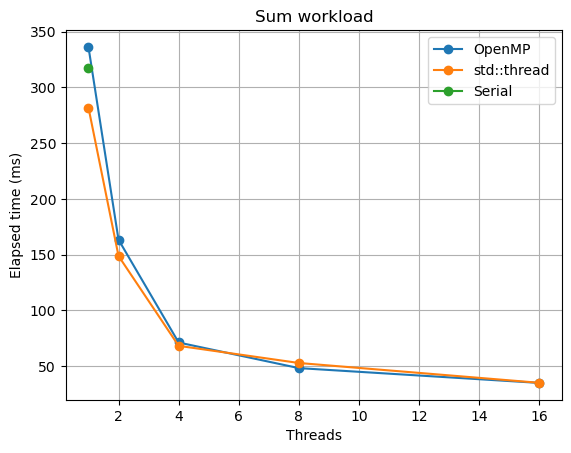

In [22]:
omp = summary[(summary["impl"] == "OMP") & (summary["workload"] == "sum")]
threads_impl = summary[(summary["impl"] == "threads") & (summary["workload"] == "sum")]
serial = summary[(summary["impl"] == "serial") & (summary["workload"] == "sum")]

plt.figure()

plt.plot(omp["threads"], omp["mean_ms"], marker='o', label="OpenMP")
plt.plot(threads_impl["threads"], threads_impl["mean_ms"], marker='o', label="std::thread")
plt.plot(serial["threads"], serial["mean_ms"], marker='o', label="Serial")

plt.xlabel("Threads")
plt.ylabel("Elapsed time (ms)")
plt.title("Sum workload")
plt.legend()
plt.grid(True)

plt.show()

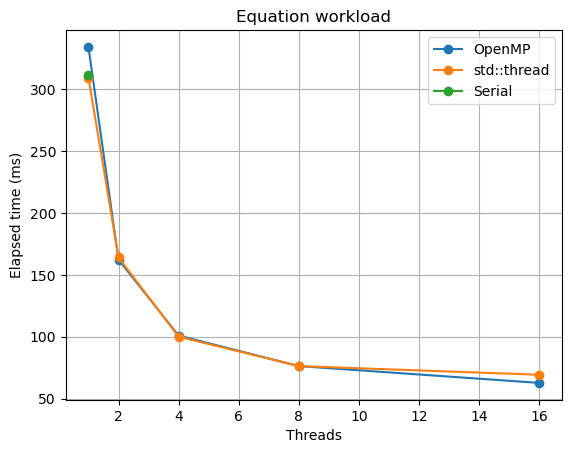

In [24]:
omp = summary[(summary["impl"] == "OMP") & (summary["workload"] == "equation")]
threads_impl = summary[(summary["impl"] == "threads") & (summary["workload"] == "equation")]
serial = summary[(summary["impl"] == "serial") & (summary["workload"] == "equation")]

plt.figure()

plt.plot(omp["threads"], omp["mean_ms"], marker='o', label="OpenMP")
plt.plot(threads_impl["threads"], threads_impl["mean_ms"], marker='o', label="std::thread")
plt.plot(serial["threads"], serial["mean_ms"], marker='o', label="Serial")

plt.xlabel("Threads")
plt.ylabel("Elapsed time (ms)")
plt.title("Equation workload")
plt.legend()
plt.grid(True)

plt.show()